# 04 - EDA Calidad De Senal Y Churn

## Hipotesis iniciales

1. Zonas con peor calidad de red deberian mostrar mayor churn posterior.
2. Deterioros en latencia, velocidad, cortes o indice global pueden anticipar abandono incluso si el cliente no contacta con soporte.
3. Las incidencias masivas pueden explicar picos locales de churn, pero su efecto podria depender del tipo de zona.
4. La relacion entre calidad y churn puede no ser lineal, por lo que deben revisarse quintiles y ranking de zonas.
5. Las variables de red deben unirse por `zona_id` y mes, evitando asignar informacion futura a clientes.

## Que se va a contrastar

- Evolucion temporal de calidad de red, latencia y cortes.
- Diferencias de churn futuro por tipo de zona y quintiles de calidad.
- Zonas con mayor churn y correlaciones de variables de red con `churn_t_plus_1`.


In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
pd.options.display.float_format = '{:,.3f}'.format

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED = PROJECT_ROOT / 'data' / 'processed'
MODELING = PROJECT_ROOT / 'data' / 'modeling'
REPORTS = PROJECT_ROOT / 'reports'

calidad = pd.read_csv(PROCESSED / 'calidad_senal_zona_mensual_clean.csv', parse_dates=['fecha'])
clientes = pd.read_csv(PROCESSED / 'clientes_clean.csv')
churn = pd.read_csv(PROCESSED / 'churn_target_clean.csv', parse_dates=['fecha'])
churn = churn.sort_values(['cliente_id', 'fecha'])
churn['churn_t_plus_1'] = churn.groupby('cliente_id')['churn'].shift(-1)
base = churn.dropna(subset=['churn_t_plus_1'])[['cliente_id', 'fecha', 'churn_t_plus_1']].merge(clientes[['cliente_id', 'zona_id']], on='cliente_id', how='left')
df = base.merge(calidad, on=['zona_id', 'fecha'], how='left')
df['churn_t_plus_1'] = df['churn_t_plus_1'].astype(int)


In [3]:
display(calidad.head())
display(df[['cliente_id','fecha','zona_id','churn_t_plus_1','indice_calidad_global']].head())


,zona_id,fecha,region,tipo_zona,poblacion_zona,cobertura_4g_pct,cobertura_5g_pct,latencia_ms,velocidad_media_mbps,tasa_cortes_pct,indice_calidad_global,incidencia_masiva,cobertura_4g_pct_was_missing,cobertura_5g_pct_was_missing,latencia_ms_was_missing
0,Z01,2023-01-01,Centro,rural,"16,625.000",82.460,4.030,56.170,30.610,3.010,18.510,0,0,0,0
1,Z01,2023-02-01,Centro,rural,"16,625.000",82.110,4.310,55.690,30.950,3.060,19.610,0,0,0,0
2,Z01,2023-03-01,Centro,rural,"16,625.000",82.190,4.560,55.450,31.050,2.960,16.990,0,0,0,0
3,Z01,2023-04-01,Centro,rural,"16,625.000",81.900,4.690,55.720,30.430,3.000,20.810,0,0,0,0
4,Z01,2023-05-01,Centro,rural,"16,625.000",81.860,5.380,55.380,30.470,3.010,18.610,0,0,0,0


,cliente_id,fecha,zona_id,churn_t_plus_1,indice_calidad_global
0,C000001,2023-01-01,Z26,0,41.270
1,C000001,2023-02-01,Z26,0,40.450
2,C000001,2023-03-01,Z26,0,39.890
3,C000001,2023-04-01,Z26,0,38.600
4,C000001,2023-05-01,Z26,0,42.450


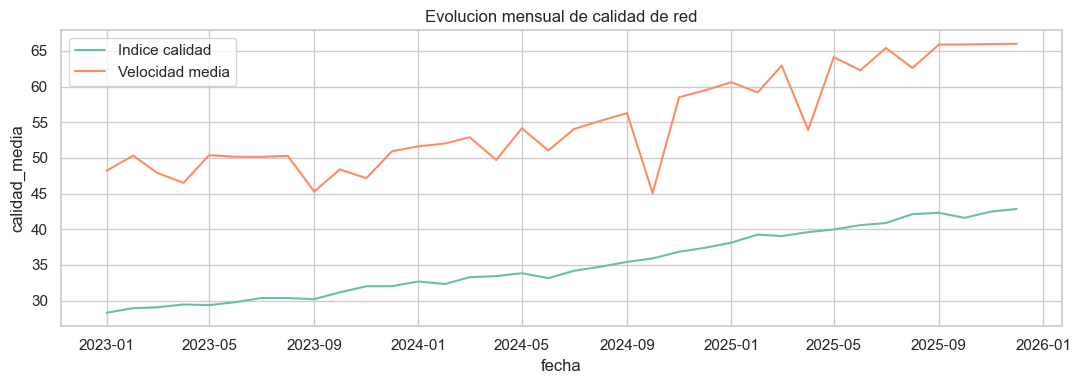

In [4]:
monthly_quality = calidad.groupby('fecha', as_index=False).agg(
    calidad_media=('indice_calidad_global', 'mean'),
    latencia_media=('latencia_ms', 'mean'),
    velocidad_media=('velocidad_media_mbps', 'mean'),
    incidencias=('incidencia_masiva', 'sum')
)
plt.figure(figsize=(11, 4))
sns.lineplot(data=monthly_quality, x='fecha', y='calidad_media', label='Indice calidad')
sns.lineplot(data=monthly_quality, x='fecha', y='velocidad_media', label='Velocidad media')
plt.title('Evolucion mensual de calidad de red')
plt.tight_layout()
plt.show()


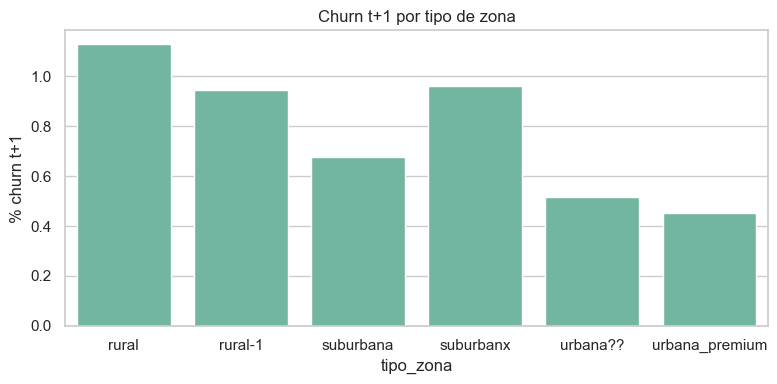

,tipo_zona,n,churn_rate
0,rural,41676,1.128
3,suburbanx,2596,0.963
1,rural-1,848,0.943
2,suburbana,120965,0.679
4,urbana??,1544,0.518
5,urbana_premium,144358,0.450


In [5]:
rates = df.groupby('tipo_zona')['churn_t_plus_1'].agg(n='count', churn_rate='mean').reset_index()
rates['churn_rate'] *= 100
plt.figure(figsize=(8, 4))
sns.barplot(data=rates, x='tipo_zona', y='churn_rate')
plt.title('Churn t+1 por tipo de zona')
plt.ylabel('% churn t+1')
plt.tight_layout()
plt.show()
display(rates.sort_values('churn_rate', ascending=False))


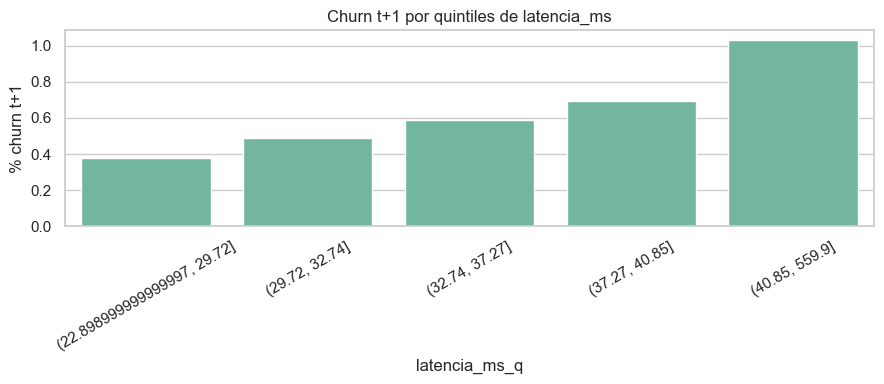

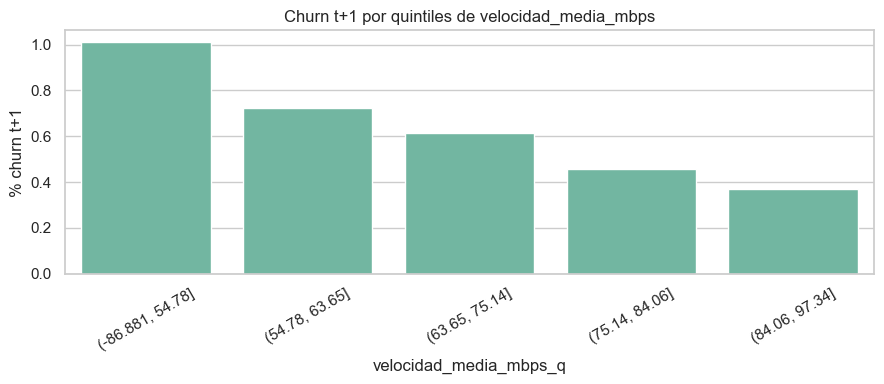

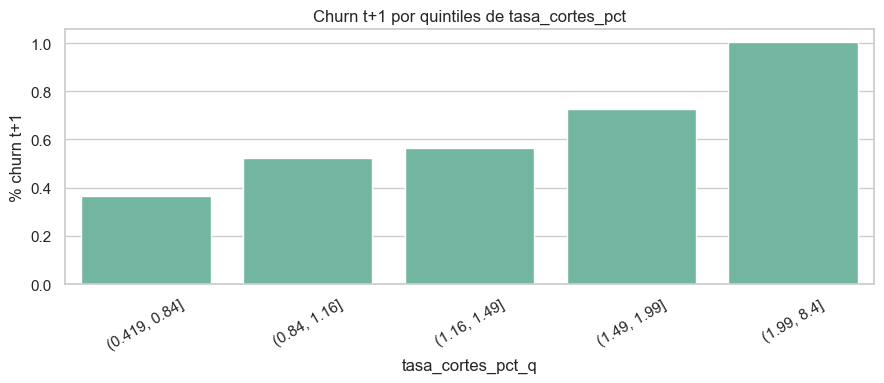

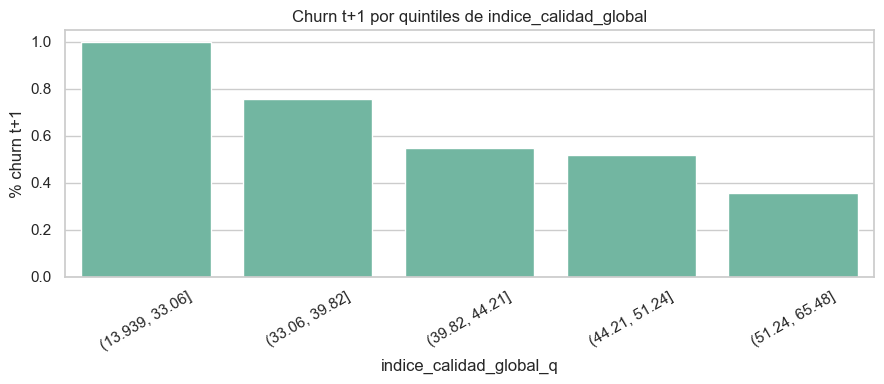

In [6]:
for col in ['latencia_ms', 'velocidad_media_mbps', 'tasa_cortes_pct', 'indice_calidad_global']:
    df[f'{col}_q'] = pd.qcut(df[col], q=5, duplicates='drop')
    rates = df.groupby(f'{col}_q')['churn_t_plus_1'].agg(n='count', churn_rate='mean').reset_index()
    rates['churn_rate'] *= 100
    plt.figure(figsize=(9, 4))
    sns.barplot(data=rates, x=f'{col}_q', y='churn_rate')
    plt.title(f'Churn t+1 por quintiles de {col}')
    plt.ylabel('% churn t+1')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


,zona_id,tipo_zona,n,churn_rate
36,Z24,rural-1,67,2.985
9,Z06,suburbanx,150,2.667
32,Z21,suburbanx,156,1.923
44,Z30,suburbanx,230,1.739
8,Z06,rural-1,278,1.439
28,Z19,rural,2868,1.360
10,Z07,rural,3505,1.312
0,Z01,rural,3547,1.269
2,Z03,rural,3958,1.263
19,Z14,rural,2563,1.210


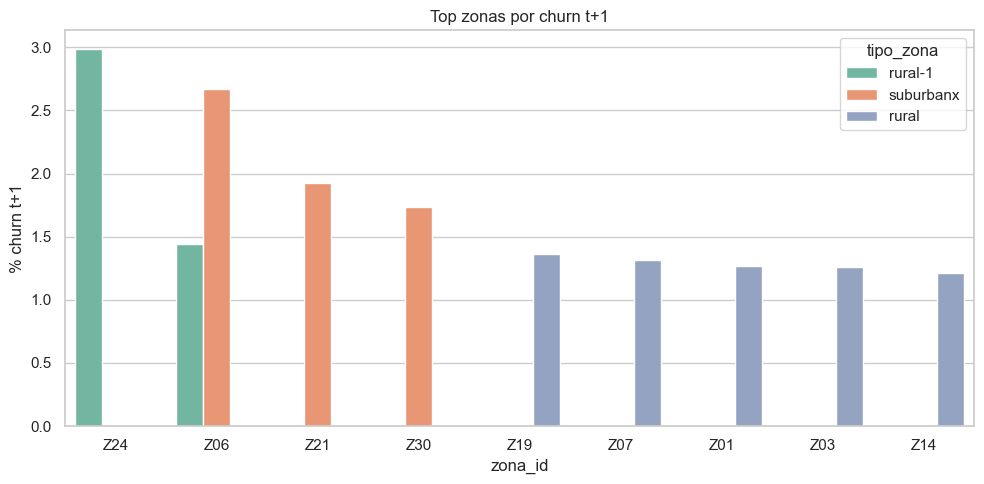

In [7]:
zone_risk = df.groupby(['zona_id', 'tipo_zona'])['churn_t_plus_1'].agg(n='count', churn_rate='mean').reset_index()
zone_risk['churn_rate'] *= 100
display(zone_risk.sort_values('churn_rate', ascending=False).head(10))
plt.figure(figsize=(10, 5))
sns.barplot(data=zone_risk.sort_values('churn_rate', ascending=False).head(10), x='zona_id', y='churn_rate', hue='tipo_zona')
plt.title('Top zonas por churn t+1')
plt.ylabel('% churn t+1')
plt.tight_layout()
plt.show()


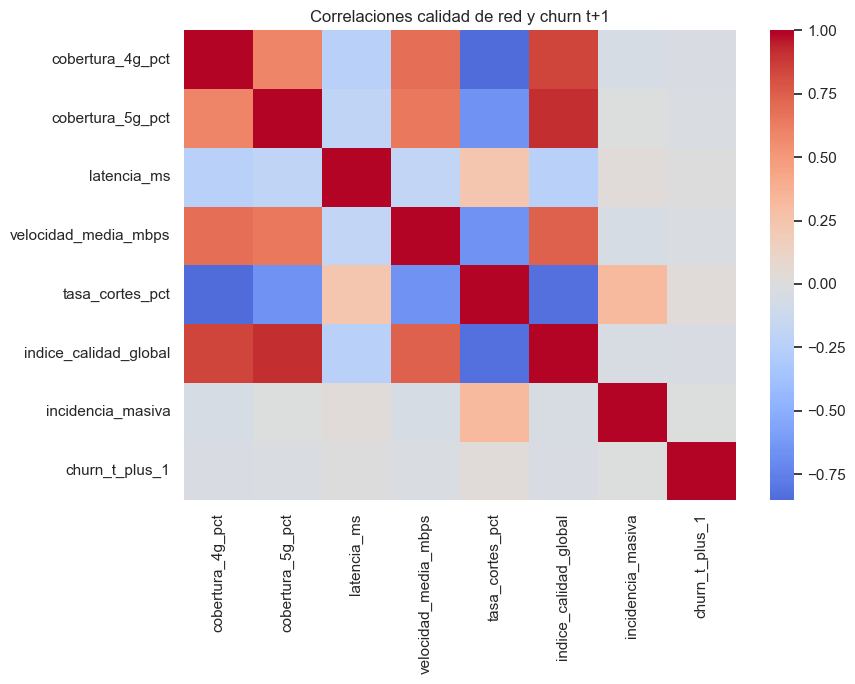

churn_t_plus_1           1.000
tasa_cortes_pct          0.027
latencia_ms              0.007
incidencia_masiva       -0.002
velocidad_media_mbps    -0.022
cobertura_5g_pct        -0.024
cobertura_4g_pct        -0.028
indice_calidad_global   -0.029
Name: churn_t_plus_1, dtype: float64

In [8]:
corr_cols = ['cobertura_4g_pct', 'cobertura_5g_pct', 'latencia_ms', 'velocidad_media_mbps', 'tasa_cortes_pct', 'indice_calidad_global', 'incidencia_masiva', 'churn_t_plus_1']
corr = df[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(9, 7))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlaciones calidad de red y churn t+1')
plt.tight_layout()
plt.show()
display(corr['churn_t_plus_1'].sort_values(ascending=False))


## Conclusiones finales

- La calidad de red aporta contexto geografico relevante y debe entrar al dataset por zona-mes, no como atributo individual del cliente.
- El churn futuro varia por tipo de zona: en la salida revisada las zonas rurales aparecen con una tasa superior, alrededor del 1.128%, frente a valores mas bajos en otros tipos de zona.
- Las variables de cortes y velocidad muestran asociaciones mas visibles que otras metricas de red; `tasa_cortes_pct` aparece con correlacion positiva y `velocidad_media_mbps` con relacion negativa frente a churn futuro.
- El analisis por quintiles y por ranking de zonas es necesario porque la relacion no parece puramente lineal y puede concentrarse en zonas concretas.
- Las diferencias territoriales pueden mezclarse con perfil de clientes, por lo que el modelo integrado debe controlar simultaneamente variables de cliente, facturacion, soporte y red.

## Decisiones para feature engineering

- Unir calidad por `zona_id` y `fecha`.
- Crear lags y rolling por zona para calidad, latencia, velocidad y cortes.
- Mantener incidencias masivas y flags de imputacion de calidad.
- Probar transformaciones por quintiles o buckets para capturar relaciones no lineales.
- Analizar falsos negativos por zona en la evaluacion final.
